# Vision Transformers (ViT) — A 3-Hour Workshop

**Prerequisites:** Basic Python, basic idea of CNNs, basic PyTorch (helpful but not mandatory — code is explained line by line)

---

## Session Plan

| Part | Topic | Duration |
|------|-------|----------|
| 1 | Theory: From CNNs to Transformers to ViT | 60 min |
| 2 | Hands-on: Building a ViT from scratch in PyTorch | 75 min |
| 3 | Using pretrained ViT, fine-tuning, attention visualization | 45 min |



---
# Part 1 — Theoretical Foundations (60 minutes)
---

## 1.1 Why do we need something beyond CNNs?

For nearly a decade (2012–2020), Convolutional Neural Networks (CNNs) were the default architecture for computer vision (AlexNet, VGG, ResNet, EfficientNet...). CNNs work well because of two **inductive biases** baked into the architecture:

- **Locality** — a convolution filter only looks at a small neighborhood of pixels.
- **Translation equivariance** — the same filter is reused across the whole image, so a shifted object still gets detected.

**Limitation**:
- CNNs struggle to model **long-range / global relationships** between distant parts of an image (e.g. relating an object in the top-left corner to one in the bottom-right).

Meanwhile in NLP, the **Transformer** (Vaswani et al., 2017, *"Attention Is All You Need"*) had already shown that **self-attention** — letting every token attend to every other token — it helps in finding relation among different words/patches in a sequence

This is the **Vision Transformer (ViT)**.

---

## 1.2 Quick recap: Self-Attention & the Transformer block

Given an input sequence of vectors (tokens) $X \in \mathbb{R}^{N \times d}$:

1. Project into **Query, Key, Value**:
$$Q = XW_Q,\quad K = XW_K,\quad V = XW_V$$

2. Compute attention scores (how much each token should "attend to" every other token):
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

3. **Multi-Head Self-Attention (MHSA)**: do this $h$ times in parallel with different learned projections, then concatenate — this lets different heads focus on different types of relationships (e.g. one head might learn color similarity, another might learn shape/edges).

4. A full **Transformer Encoder block** wraps MHSA with residual connections, LayerNorm, and a small feed-forward (MLP) network:

```
x = x + MHSA(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```

This is called the **Pre-LN Transformer block**, and it's exactly what ViT uses.

 *Why is $\sqrt{d_k}$ used to scale the dot product?* (Answer: without scaling, dot products grow large in magnitude as $d_k$ increases, pushing softmax into regions with vanishingly small gradients.)

---

## 1.3 The core idea of ViT: "An image is worth 16×16 words"

Transformers expect a **sequence of tokens** (like word embeddings in NLP). An image is a grid of pixels, not a sequence. ViT's trick is remarkably simple:

> **Cut the image into fixed-size patches (e.g. 16×16 pixels), flatten each patch, and linearly project it into an embedding — exactly like a "word" in NLP.**

That's it. No convolutions required (in the original, pure ViT). The rest of the network is a **vanilla Transformer encoder**, identical in spirit to BERT.



### Step-by-step ViT architecture

Given an input image $x \in \mathbb{R}^{H \times W \times C}$:

**Step 1 — Patchify.**
Split the image into $N$ non-overlapping patches of size $P \times P$:
$$N = \frac{H \times W}{P^2}$$
For a 224×224 image with patch size 16, $N = \frac{224 \times 224}{16 \times 16} = 196$ patches.

**Step 2 — Patch (Linear) Embedding.**
Each patch is flattened into a vector of length $P^2 \cdot C$ and linearly projected into a $D$-dimensional embedding (this projection is literally a single `Linear` layer, or equivalently a `Conv2d` with kernel size = stride = patch size).

**Step 3 — Prepend a learnable [CLS] token.**
Just like BERT's `[CLS]` token, a special learnable embedding is prepended to the sequence of patch embeddings. After passing through the Transformer, this token's final representation is used for classification — it acts as a summary of the whole image.

**Step 4 — Add Positional Embeddings.**
Self-attention has **no notion of order or position** — it treats input as a *set*, not a sequence. But patch position matters (a sky patch at the top means something different than at the bottom). So a learnable positional embedding is **added** (not concatenated) to every patch embedding.

**Step 5 — Transformer Encoder.**
The sequence of $(N+1)$ embeddings (patches + CLS) is passed through $L$ standard Transformer encoder blocks (MHSA + MLP, as described in 1.2).

**Step 6 — Classification Head.**
The final CLS token representation is passed through a small MLP (usually just one `Linear` layer during fine-tuning) to produce class logits.

### Putting it together (diagram, describe verbally / draw on board):

```
Image (224x224x3)
   |
   v
[Split into 16x16 patches] --> 196 patches
   |
   v
[Linear projection of each flattened patch]  --> 196 x D embeddings
   |
   v
[Prepend CLS token]  --> 197 x D
   |
   v
[+ Positional Embedding]  --> 197 x D
   |
   v
[Transformer Encoder Block] x L   (MHSA + MLP, residuals, LayerNorm)
   |
   v
[Take CLS token output]
   |
   v
[MLP Head] --> class logits
```

** Note** *A 16×16 patch of a 224×224 RGB image has how many raw pixel values?* ($16 \times 16 \times 3 = 768$). Interesting coincidence: ViT-Base's embedding dimension $D$ is also 768!

---

## 1.4 Where ViT is used today

Image classification, object detection (DETR-style), segmentation, multimodal models (CLIP uses a ViT as its image encoder), and as the vision backbone in most modern vision-language and generative models.

---


---
# Part 2 — Hands-on: Building a Vision Transformer from Scratch (75 minutes)
---

We will now implement **every component described in Part 1** in PyTorch, piece by piece, then assemble a complete working ViT and train it on a small dataset so the whole workshop runs in a live session without needing a GPU cluster.

**Teaching flow for this part:**
1. Patch Embedding (10 min)
2. Multi-Head Self-Attention (15 min)
3. Transformer Encoder Block (10 min)
4. Full ViT assembly (10 min)
5. Sanity check with dummy input (5 min)
6. Train on a small dataset (MNIST, resized) (20 min)
7. Visualize patches / attention (5 min)

### 2.0 Environment setup


In [1]:
# Core imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 2.1 Patch Embedding

**Concept:** Split image into patches, flatten, linearly project.

**Implementation trick:** Instead of manually slicing the image into patches and flattening, we use a single `nn.Conv2d` with `kernel_size = patch_size` and `stride = patch_size`. This performs the "split + flatten + linear project" operation in one efficient GPU-friendly op — a very common trick worth pointing out to faculty, since it's not obvious the first time you see it.

- Input: `(B, C, H, W)`
- Output of Conv2d: `(B, D, H/P, W/P)`
- We then flatten the spatial dims and transpose to get `(B, N, D)` — a sequence of N patch embeddings of dimension D, exactly what a Transformer expects.


In [2]:
class PatchEmbedding(nn.Module):
    """Splits image into patches and linearly embeds each patch."""
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d with kernel=stride=patch_size does "slice + flatten + linear project" in one shot
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)                # (B, D, H/P, W/P)
        x = x.flatten(2)                # (B, D, N)
        x = x.transpose(1, 2)           # (B, N, D)  -> sequence of patch embeddings
        return x

# Quick sanity check
patch_embed = PatchEmbedding(img_size=28, patch_size=7, in_channels=1, embed_dim=64)
dummy_img = torch.randn(2, 1, 28, 28)   # batch of 2 grayscale 28x28 images (MNIST-like)
out = patch_embed(dummy_img)
print("Input shape :", dummy_img.shape)
print("Output shape:", out.shape, " -> (batch, num_patches, embed_dim)")
print("Number of patches:", patch_embed.num_patches)

Input shape : torch.Size([2, 1, 28, 28])
Output shape: torch.Size([2, 16, 64])  -> (batch, num_patches, embed_dim)
Number of patches: 16


## 2.2 Multi-Head Self-Attention (MHSA)

This is a direct implementation of the formula from Part 1:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

done

In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5   # 1/sqrt(d_k)

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)   # combined Q,K,V projection
        self.proj = nn.Linear(embed_dim, embed_dim)      # output projection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        B, N, D = x.shape   # batch, num_tokens (patches+CLS), embed_dim

        qkv = self.qkv(x)                                        # (B, N, 3D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                          # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn_scores = (q @ k.transpose(-2, -1)) * self.scale     # (B, heads, N, N)
        attn_weights = attn_scores.softmax(dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = attn_weights @ v                                   # (B, heads, N, head_dim)
        out = out.transpose(1, 2).reshape(B, N, D)                # concat heads -> (B, N, D)
        out = self.proj(out)

        if return_attention:
            return out, attn_weights
        return out

# Sanity check
mhsa = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
dummy_seq = torch.randn(2, 17, 64)   # e.g. 16 patches + 1 CLS token
out = mhsa(dummy_seq)
print("Input shape :", dummy_seq.shape)
print("Output shape:", out.shape, " (unchanged - attention preserves shape)")


Input shape : torch.Size([2, 17, 64])
Output shape: torch.Size([2, 17, 64])  (unchanged - attention preserves shape)


## 2.3 Transformer Encoder Block

Implements the **Pre-LN** block from Part 1:

```
x = x + MHSA(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```

The MLP is a simple two-layer feed-forward network with a GELU activation, expanding to `mlp_ratio * embed_dim` and projecting back down — this is where most of ViT's parameters live.


In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # residual connection around attention
        x = x + self.mlp(self.norm2(x))    # residual connection around MLP
        return x

# Sanity check
block = TransformerEncoderBlock(embed_dim=64, num_heads=4)
out = block(dummy_seq)
print("Output shape:", out.shape, "(same shape - blocks can be stacked)")

Output shape: torch.Size([2, 17, 64]) (same shape - blocks can be stacked)


## 2.4 Assembling the Full ViT

Now we combine everything from Part 1:

1. `PatchEmbedding` — image -> sequence of patch embeddings
2. Prepend a learnable **[CLS] token**
3. Add a learnable **positional embedding**
4. Pass through `L` stacked `TransformerEncoderBlock`s
5. Take the CLS token's final representation -> classification head (`Linear` layer)


In [5]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, num_classes=10,
                 embed_dim=64, depth=4, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)   # classification head

        # weight init (standard practice for ViT)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, return_attention=False):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, N, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)     # (B, 1, D)
        x = torch.cat((cls_tokens, x), dim=1)              # (B, N+1, D)
        x = x + self.pos_embed                             # add positional info
        x = self.pos_drop(x)

        attn_maps = []
        for block in self.blocks:
            if return_attention:
                x_norm = block.norm1(x)
                _, attn = block.attn(x_norm, return_attention=True)
                attn_maps.append(attn)
            x = block(x)

        x = self.norm(x)
        cls_out = x[:, 0]                                  # take CLS token representation
        logits = self.head(cls_out)

        if return_attention:
            return logits, attn_maps
        return logits

# Build a small ViT suited for MNIST (28x28 grayscale, 10 classes)
model = VisionTransformer(
    img_size=28, patch_size=7, in_channels=1, num_classes=10,
    embed_dim=64, depth=4, num_heads=4, mlp_ratio=4.0, dropout=0.1
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 64, kernel_size=(7, 7), stride=(7, 7))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=64, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=10, 

In [ ]:
# Sanity check with dummy input, and confirm output shape = (batch, num_classes)
dummy_batch = torch.randn(4, 1, 28, 28).to(device)
logits = model(dummy_batch)
print("Logits shape:", logits.shape, "-> (batch_size, num_classes)")


## 2.5 Training on MNIST (small, fast, fits any laptop)

For a live 3-hour, use **MNIST** (not ImageNet!) so that:
- Every participant can train this on a CPU-only laptop in a few minutes.
- The focus stays on **understanding the architecture**, not on managing large datasets/GPUs.

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])   # keep 28x28, single channel

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# For a quick in-session demo, use a subset (comment out for full training)
train_subset = torch.utils.data.Subset(train_dataset, range(6000))
test_subset  = torch.utils.data.Subset(test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=64, shuffle=False)

print("Train samples used:", len(train_subset))
print("Test samples used :", len(test_subset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 146MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 16.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 44.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.62MB/s]


Train samples used: 6000
Test samples used : 1000


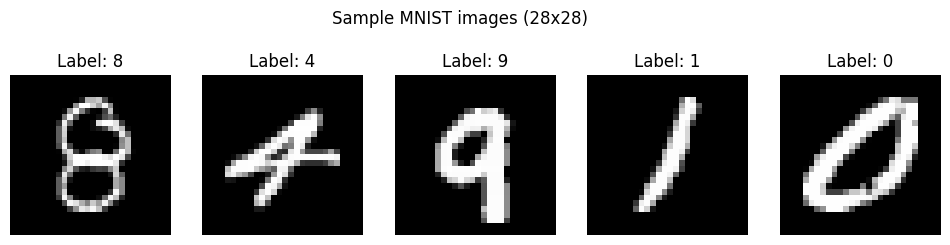

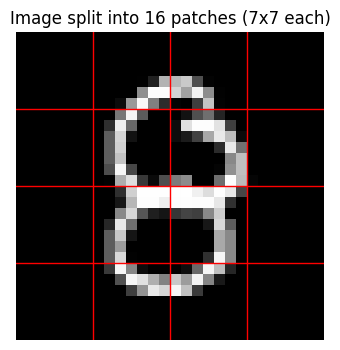

In [7]:
# Visualize a few sample images and their patch grid, to make Section 1.3 concrete
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(images[i][0], cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
plt.suptitle("Sample MNIST images (28x28)")
plt.show()

# Overlay the 7x7 patch grid (patch_size=7 -> 4x4=16 patches) on one image
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(images[0][0], cmap="gray")
for i in range(1, 4):
    ax.axhline(i * 7 - 0.5, color="red", linewidth=1)
    ax.axvline(i * 7 - 0.5, color="red", linewidth=1)
ax.set_title("Image split into 16 patches (7x7 each)")
ax.axis("off")
plt.show()


In [8]:
# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

EPOCHS = 5   # keep small for live demo; increase for better accuracy if time allows

train_losses, test_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(train_subset)
    acc = evaluate(model, test_loader)
    train_losses.append(epoch_loss)
    test_accs.append(acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Test Accuracy: {acc*100:.2f}%")


Epoch 1/5 | Train Loss: 1.7627 | Test Accuracy: 53.30%
Epoch 2/5 | Train Loss: 1.2171 | Test Accuracy: 63.10%
Epoch 3/5 | Train Loss: 0.9919 | Test Accuracy: 68.40%
Epoch 4/5 | Train Loss: 0.8054 | Test Accuracy: 75.80%
Epoch 5/5 | Train Loss: 0.6744 | Test Accuracy: 79.10%


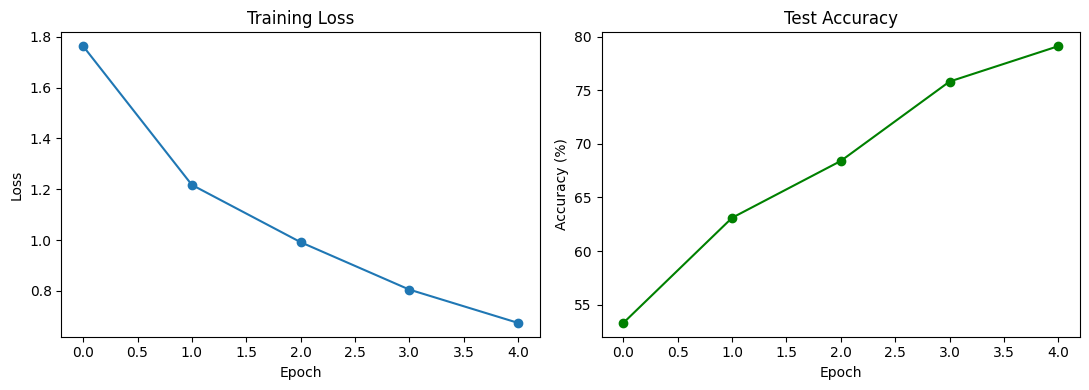

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot([a*100 for a in test_accs], marker="o", color="green")
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()


## 2.6 Visualizing What the Model's Attention Looks At

Because our `forward(..., return_attention=True)` returns the raw attention weights from every block, we can visualize **how much the CLS token attends to each patch** 


True label: 7 | Predicted: 7


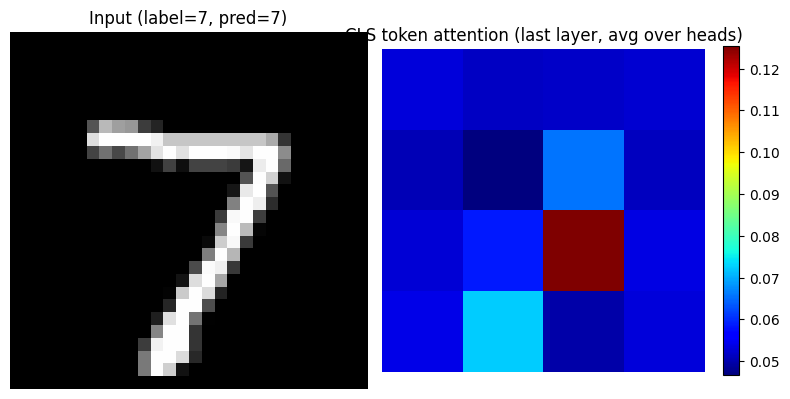

Notice how brighter cells correspond to patches the CLS token 'relies on' most for its final decision.


In [10]:
model.eval()
sample_img, sample_label = test_dataset[0]
sample_img_batch = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    logits, attn_maps = model(sample_img_batch, return_attention=True)

pred = logits.argmax(dim=1).item()
print(f"True label: {sample_label} | Predicted: {pred}")

# attn_maps is a list (per layer) of tensors (B, heads, N, N); N = num_patches+1 (CLS + 16 patches)
last_layer_attn = attn_maps[-1][0]          # (heads, N, N) for the last block
cls_attn = last_layer_attn[:, 0, 1:]        # attention FROM cls token TO each patch, per head
cls_attn_avg = cls_attn.mean(dim=0)         # average across heads -> (num_patches,)

grid_size = int(cls_attn_avg.shape[0] ** 0.5)   # 4x4 grid for 16 patches
attn_grid = cls_attn_avg.reshape(grid_size, grid_size).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img[0], cmap="gray")
axes[0].set_title(f"Input (label={sample_label}, pred={pred})")
axes[0].axis("off")

im = axes[1].imshow(attn_grid, cmap="jet")
axes[1].set_title("CLS token attention (last layer, avg over heads)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

print("Notice how brighter cells correspond to patches the CLS token 'relies on' most for its final decision.")


---
# Part 3 — Pretrained ViT, Fine-tuning, and Attention Rollout (45 minutes)
---

Training a ViT from scratch (Part 2) is great for teaching the architecture, but in practice **nobody trains ViT from scratch** on small/medium datasets — this is precisely the "data hungry" limitation from Section 1.4. In real projects, you will almost always:

1. Load a model **pretrained on ImageNet** (or larger) via `timm` or Hugging Face `transformers`.
2. **Fine-tune** only the classification head (or the whole model with a small learning rate) on their own dataset.
3. Use the pretrained model's attention maps to interpret predictions.

**Flow for this part:**
1. Install / import `timm` (10 min)
2. Load a pretrained ViT, inspect its architecture (10 min)
3. Fine-tune the head on a small custom-style dataset (15 min)
4. Visualize attention using **attention rollout** (10 min)

### 3.1 Install and load a pretrained ViT


In [11]:
# timm ("PyTorch Image Models") provides easy access to pretrained ViT checkpoints
# Run this cell once; if offline during the workshop, skip Part 3 or pre-download beforehand.
import subprocess, sys
try:
    import timm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "timm", "--break-system-packages", "-q"])
    import timm

print("timm version:", timm.__version__)

# List a few available ViT variants
vit_models = [m for m in timm.list_models("vit_*") if "small" in m or "tiny" in m][:10]
print("\nSample available ViT variants:")
for m in vit_models:
    print(" -", m)


timm version: 1.0.27

Sample available ViT variants:
 - vit_pe_core_small_patch16_384
 - vit_pe_core_tiny_patch16_384
 - vit_pe_spatial_small_patch16_512
 - vit_pe_spatial_tiny_patch16_512
 - vit_relpos_small_patch16_224
 - vit_relpos_small_patch16_rpn_224
 - vit_small_patch8_224
 - vit_small_patch14_dinov2
 - vit_small_patch14_reg4_dinov2
 - vit_small_patch16_18x2_224


In [12]:
# Load a small pretrained ViT (fast to run in a live workshop)
pretrained_model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=10)
pretrained_model = pretrained_model.to(device)

print(pretrained_model.default_cfg)
n_params = sum(p.numel() for p in pretrained_model.parameters())
print(f"\nTotal parameters: {n_params:,}")


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

{'url': 'https://storage.googleapis.com/vit_models/augreg/S_16-i21k-300ep-lr_0.001-aug_light1-wd_0.03-do_0.0-sd_0.0--imagenet2012-steps_20k-lr_0.03-res_224.npz', 'hf_hub_id': 'timm/vit_small_patch16_224.augreg_in21k_ft_in1k', 'architecture': 'vit_small_patch16_224', 'tag': 'augreg_in21k_ft_in1k', 'custom_load': True, 'input_size': (3, 224, 224), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 0.9, 'crop_mode': 'center', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'num_classes': 1000, 'pool_size': None, 'first_conv': 'patch_embed.proj', 'classifier': 'head', 'license': 'apache-2.0'}

Total parameters: 21,669,514



### 3.2 Freezing the backbone and fine-tuning only the head

This is the fastest and most common approach when you have limited data or limited compute — relevant for those who do not have access to big GPUs.


In [13]:
# Freeze all backbone parameters, only train the classification head
for name, param in pretrained_model.named_parameters():
    if "head" not in name:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in pretrained_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
      f"({100*trainable_params/total_params:.3f}% of the model)")

Trainable parameters: 3,850 / 21,669,514 (0.018% of the model)


In [14]:
# Prepare MNIST resized+repeated to 3-channel 224x224 to match ViT's expected input.
# NOTE: this is only for demonstration; in a live session, using a small subset keeps this fast.
from torchvision import transforms

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # ViT pretrained on RGB (3-channel) ImageNet
    transforms.ToTensor(),
])

ft_train = datasets.MNIST(root="./data", train=True, download=True, transform=vit_transform)
ft_test  = datasets.MNIST(root="./data", train=False, download=True, transform=vit_transform)

# Small subsets so this finishes quickly during a live session
ft_train_subset = torch.utils.data.Subset(ft_train, range(500))
ft_test_subset  = torch.utils.data.Subset(ft_test, range(200))

ft_train_loader = DataLoader(ft_train_subset, batch_size=16, shuffle=True)
ft_test_loader  = DataLoader(ft_test_subset, batch_size=16, shuffle=False)

print("Fine-tuning train samples:", len(ft_train_subset))
print("Fine-tuning test samples :", len(ft_test_subset))


Fine-tuning train samples: 500
Fine-tuning test samples : 200


In [15]:
# Took 10 minutes for 2 epocs
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()), lr=1e-3
)
criterion = nn.CrossEntropyLoss()

FT_EPOCHS = 2   # kept tiny for a live workshop demo

for epoch in range(FT_EPOCHS):
    pretrained_model.train()
    running_loss = 0.0
    for x, y in ft_train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = pretrained_model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    acc = evaluate(pretrained_model, ft_test_loader)
    print(f"Epoch {epoch+1}/{FT_EPOCHS} | Loss: {running_loss/len(ft_train_subset):.4f} | Test Acc: {acc*100:.2f}%")


Epoch 1/2 | Loss: 1.8341 | Test Acc: 65.00%
Epoch 2/2 | Loss: 0.9574 | Test Acc: 77.00%


**Observation:** Even with only ~500 training images and 2 epochs, fine-tuning a pretrained ViT typically reaches much higher accuracy far faster than training the from-scratch ViT of Part 2 — a direct, visible demonstration of the value of large-scale pretraining. Compare the two accuracy numbers on the board.



## Wrap-up: Key Takeaways for Faculty to Carry Back to Class

1. **ViT treats an image as a sequence of patches** — "words" — and applies the standard NLP Transformer encoder unchanged.
2. The three learnable additions beyond a vanilla Transformer are: **patch embedding projection, a CLS token, and positional embeddings.**
3. ViT has **weaker inductive bias** than CNNs → needs **more data / pretraining** to perform well, but scales better with data and compute.
4. In practice, **use pretrained checkpoints and fine-tune** (via `timm` / Hugging Face) rather than training from scratch — exactly like CNN transfer learning, just with a different backbone.
5. **Attention maps / attention rollout** give a natural, built-in interpretability tool, analogous to Grad-CAM for CNNs.

## Suggested Exercises for Participants (post-workshop / assignment)

1. Change `patch_size` in the from-scratch ViT (Part 2) from 7 to 4 or 14. How do the number of patches, parameter count, and accuracy change?
2. Increase `depth` and `num_heads` in the from-scratch model. Does deeper/wider always help on a small dataset like MNIST-6000? Why or why not?
3. Repeat Part 3's fine-tuning experiment using a real small image dataset from your own domain (e.g. a subset of `CIFAR-10`, or a custom dataset of course-relevant images) and report accuracy before/after fine-tuning.
4. Compare a small CNN (e.g. `resnet18` from `timm`, trained from scratch) against the from-scratch ViT of Part 2 on the same MNIST subset. Which wins with limited data? Does the outcome change if you increase the amount of training data?
5. Try visualizing attention rollout for a **misclassified** image. Does the attention map give any hint about *why* the model got it wrong?
